In [7]:
# 환경 준비 - 라이브러리 불러오기와 한글 폰트 설정
import os
import platform
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

if platform.system() == "Windows":
    plt.rcParams["font.family"] = "Malgun Gothic"  # 맑은 고딕
else:
    nanum_path = "/usr/share/fonts/truetype/nanum/NanumGothic.ttf"
    if os.path.exists(nanum_path):
        fm.fontManager.addfont(nanum_path)
        plt.rcParams["font.family"] = "NanumGothic"
    else:
        pass

plt.rcParams["axes.unicode_minus"] = False  # 마이너스 기호 안 깨지게
print("적용된 폰트:", plt.rcParams["font.family"])

# Colab에서는 CSV를 노트북과 같은 위치에 올려두고, 로컬에서는 ../Data 에서 읽음
DATA_DIR = os.path.join("..", "Data") if os.path.isdir(os.path.join("..", "Data")) else "."

적용된 폰트: ['Malgun Gothic']


---
## 실습 1 - 막대 그래프 직접 그리기
`설비별 평균 온도를 막대로, 색·가로 막대로 변형`

배치
로트A    858.42
로트B    859.81
로트C    860.42
Name: 온도, dtype: float64


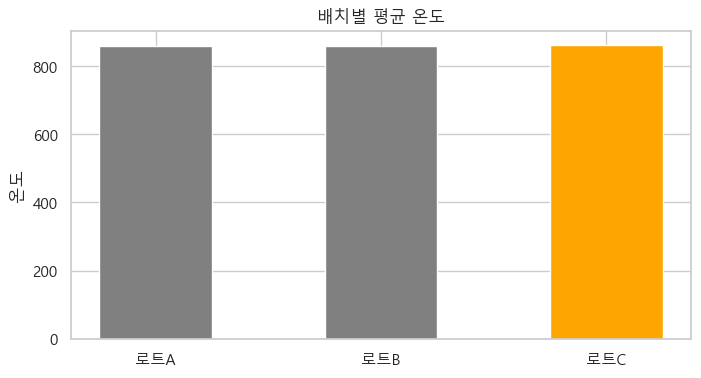

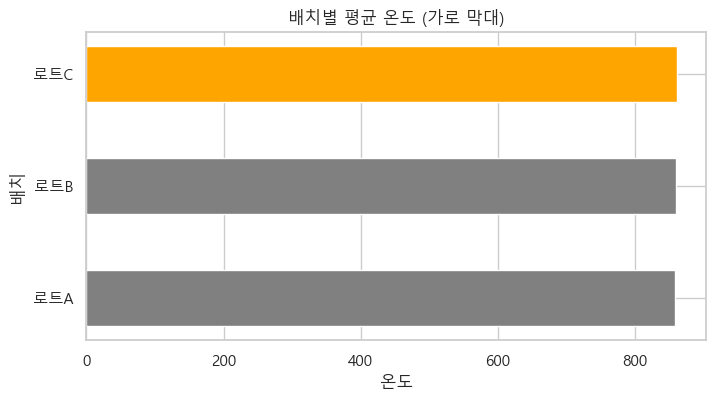

In [8]:
path_1 = os.path.join(DATA_DIR, "17_열처리.csv")
df_1 = pd.read_csv(path_1, encoding="utf-8")

# groupby로 설비별 평균 온도를 구해 막대로 그리기
avg_1 = df_1.groupby("배치")["온도"].mean()
print(avg_1.round(2))  # 값을 확인해서 잘 계산되었는지부터 봅시다!

# 색 리스트로 가장 뜨거운 설비만 강조하고 너비 조절
# avg_1의 index labels가 x축, values가 막대 높이가 됨
plt.figure(figsize=(8, 4))
plt.bar(avg_1.index, avg_1.values, color=["gray", "gray", "orange"], width=0.5)
plt.title("배치별 평균 온도")
plt.ylabel("온도")
plt.show()

# barh로 가로 막대로 바꾸고 제목, 축 이름 붙이기
plt.figure(figsize=(8, 4))
plt.barh(avg_1.index, avg_1.values, color=["gray", "gray", "orange"], height=0.5)
plt.title("배치별 평균 온도 (가로 막대)")
plt.xlabel("온도")
plt.ylabel("배치")
plt.show()

---
## 실습 2 - 범주별 집계 막대 그래프
`개수, 평균을 집계해 범주별로 막대 비교`

상태
정상    42
승온     2
Name: count, dtype: int64


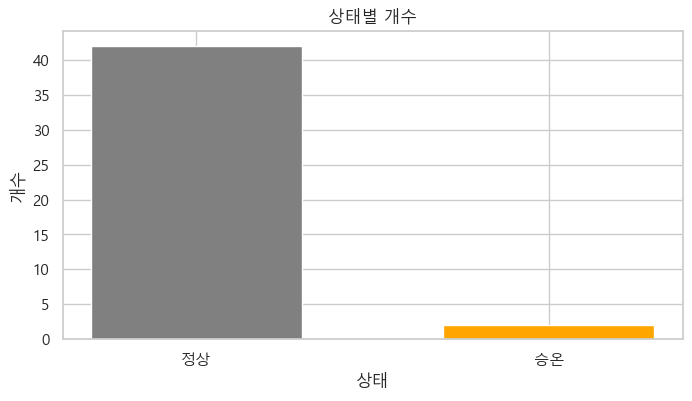

배치
로트A    81.91
로트B    75.84
로트C    69.62
Name: OP값, dtype: float64


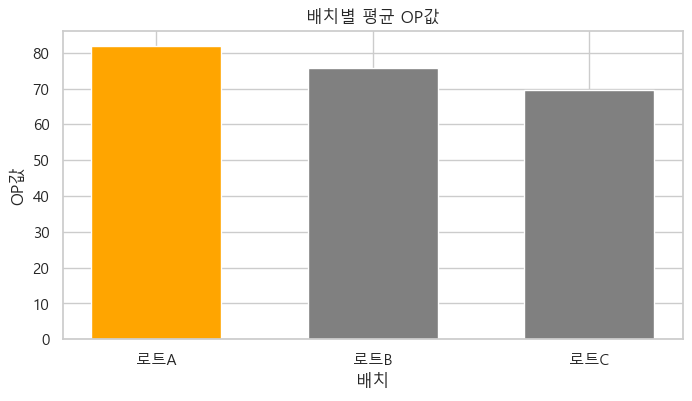

In [13]:
# 상태 열의 개수를 세어 막대로 그리기
path_2 = os.path.join(DATA_DIR, "17_열처리.csv")
df_2 = pd.read_csv(path_2, encoding="utf-8")

status_2 = df_2["상태"].value_counts()
print(status_2)

plt.figure(figsize=(8, 4))
plt.bar(status_2.index, status_2.values, color=["gray", "orange"], width=0.6)
plt.title("상태별 개수")
plt.xlabel("상태")
plt.ylabel("개수")
plt.show()

# 배치로 그룹을 나눠 평균 OP값을 막대로 그리기
op_2 = df_2.groupby("배치")["OP값"].mean()
print(op_2.round(2))

# 제목, 축 이름을 붙여 완성
plt.figure(figsize=(8, 4))
plt.bar(op_2.index, op_2.values, color=["orange", "gray", "gray"], width=0.6)
plt.title("배치별 평균 OP값")
plt.xlabel("배치")
plt.ylabel("OP값")
plt.show()

---
## 실습 3 - 히스토그램 직접 그리기
`온도 분포를 히스토그램으로, bins로 구간 조절`

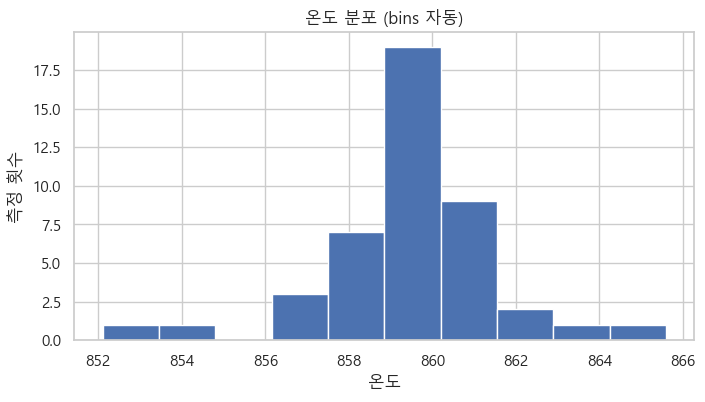

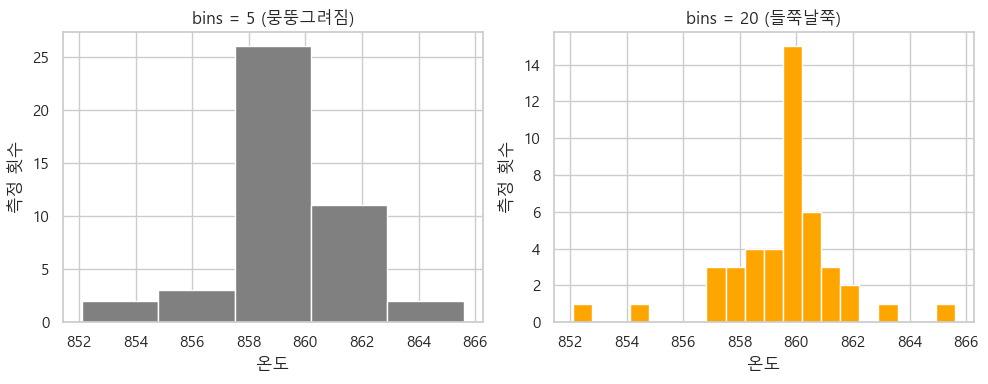

In [14]:
# 온도 열을 hist로 그려 자동 구간 분포 확인
path_3 = os.path.join(DATA_DIR, "17_열처리.csv")
df_3 = pd.read_csv(path_3, encoding="utf-8")

plt.figure(figsize=(8, 4))
plt.hist(df_3["온도"])  # bins를 안 주면 기본 10구간
plt.title("온도 분포 (bins 자동)")
plt.xlabel("온도")
plt.ylabel("측정 횟수")
plt.show()

# bins를 작게, 크게 바꿔 구간 수에 따른 모양 비교
# 구간이 적으면 뭉뚱그려 보이고, 많으면 들쭉날쭉해 보임
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.hist(df_3["온도"], bins=5, color="gray")
plt.title("bins = 5 (뭉뚱그려짐)")
plt.xlabel("온도")
plt.ylabel("측정 횟수")

plt.subplot(1, 2, 2)
plt.hist(df_3["온도"], bins=20, color="orange")
plt.title("bins = 20 (들쭉날쭉)")
plt.xlabel("온도")
plt.ylabel("측정 횟수")

plt.tight_layout()  # 칸 겹침 제거, 습관적으로 show 앞에 적용
plt.show()

---
## 실습 4 - 센서값 분포 히스토그램
`분포를 그리고 평균, 표준편차, 이상 설비로 해석`

평균: 859.532 | 표준편차: 2.105
862도 이상 측정 건수: 2
     측정시각   배치     온도  상태
25  10:40  로트B  862.9  정상
32  09:30  로트C  865.6  정상


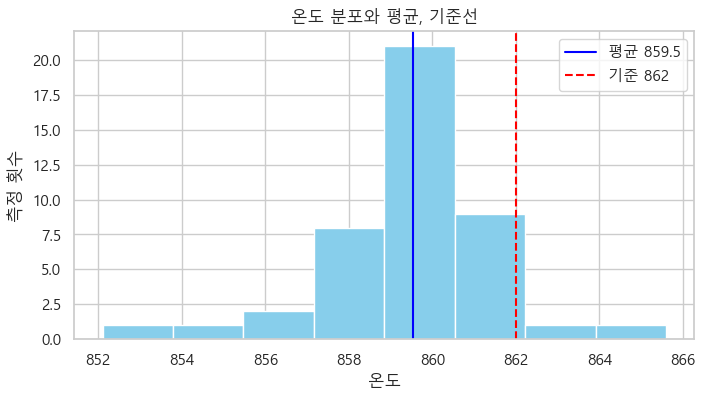

In [16]:
# 평균과 표준편차를 구해 분포의 중심, 퍼짐과 비교
path_4 = os.path.join(DATA_DIR, "17_열처리.csv")
df_4 = pd.read_csv(path_4, encoding="utf-8")

mean_4 = df_4["온도"].mean()
std_4 = df_4["온도"].std()
print("평균:", round(mean_4, 3), "| 표준편차:", round(std_4, 3))

# 조건 필터링으로 정상 범위를 벗어난 설비 수 확인
high_4 = df_4[df_4["온도"] >= 862]
print("862도 이상 측정 건수:", len(high_4))
print(high_4[["측정시각", "배치", "온도", "상태"]])

# 온도 분포를 히스토그램으로 그리고 평균, 기준선을 함께 표시
plt.figure(figsize=(8, 4))
plt.hist(df_4["온도"], bins=8, color="skyblue", edgecolor="white")
plt.axvline(x=mean_4, color="blue", linestyle="-", label=f"평균 {mean_4:.1f}")
plt.axvline(x=862, color="red", linestyle="--", label="기준 862")
plt.title("온도 분포와 평균, 기준선")
plt.xlabel("온도")
plt.ylabel("측정 횟수")
plt.legend()
plt.show()

# [해석]
# 평균 859.5도를 중심으로 표준편차 2.1도라 대부분 857~862도 사이에 몰려 있음
# 862도 이상은 44건 중 2건뿐이고, 둘 다 상태가 승온으로 기록된 구간

---
## 실습 5 - 산점도로 센서 간 관계 분석
`온도-OP값 산점도에 상태별 색, 기준선 추가`

온도와 OP값의 상관계수: -0.783


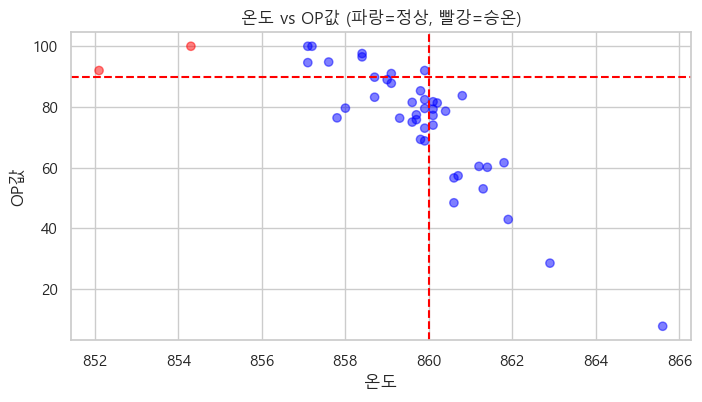

In [17]:
# 온도와 OP값을 산점도로 찍어 관계 확인
path_5 = os.path.join(DATA_DIR, "17_열처리.csv")
df_5 = pd.read_csv(path_5, encoding="utf-8")

# 상관계수를 먼저 구해 눈으로 본 관계와 숫자를 대조
r_5 = df_5["온도"].corr(df_5["OP값"])
print("온도와 OP값의 상관계수:", round(r_5, 3))

# 상태를 색으로 매핑해 정상, 승온을 색으로 구분
colors_5 = df_5["상태"].map({"정상": "blue", "승온": "red"})

plt.figure(figsize=(8, 4))
plt.scatter(df_5["온도"], df_5["OP값"], color=colors_5, alpha=0.5)

# axhline, axvline으로 임계 기준선 그리기
plt.axhline(y=90.0, color="red", linestyle="--")  # 기준선
plt.axvline(x=860.0, color="red", linestyle="--")

plt.title("온도 vs OP값 (파랑=정상, 빨강=승온)")
plt.xlabel("온도")
plt.ylabel("OP값")
plt.show()

# [해석]
# 상관계수 -0.783으로 강한 "음"의 관계 -> 온도가 오르면 OP값은 내려감
# 오른쪽 아래(고온-저OP) 구석에 빨간 점(승온)이 몰려 있음

---
## 실습 6 - 온도와 CP값의 관계 분석
`실습 5를 참고해 온도-CP값 산점도를 그리고 관계 판단`

온도 ~ OP값 : -0.783
온도 ~ CP값 : 0.022


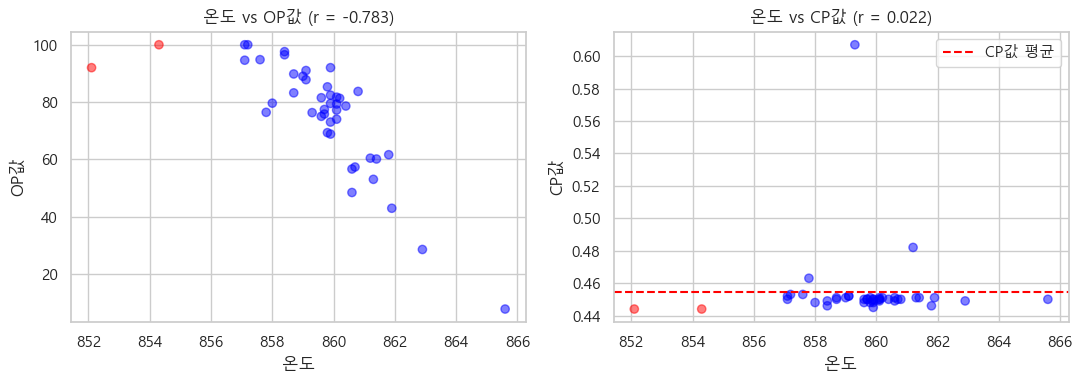

In [18]:
# 실습 5와 같은 방식으로 온도와 CP값의 산점도 그리기
path_6 = os.path.join(DATA_DIR, "17_열처리.csv")
df_6 = pd.read_csv(path_6, encoding="utf-8")

# 두 관계의 상관계수를 나란히 구해 비교
r_op = df_6["온도"].corr(df_6["OP값"])
r_cp = df_6["온도"].corr(df_6["CP값"])
print("온도 ~ OP값 :", round(r_op, 3))
print("온도 ~ CP값 :", round(r_cp, 3))

colors_6 = df_6["상태"].map({"정상": "blue", "승온": "red"})

# 두 산점도를 나란히 놓고 모양 차이를 눈으로 확인
plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.scatter(df_6["온도"], df_6["OP값"], color=colors_6, alpha=0.5)
plt.title(f"온도 vs OP값 (r = {r_op:.3f})")
plt.xlabel("온도")
plt.ylabel("OP값")

plt.subplot(1, 2, 2)
plt.scatter(df_6["온도"], df_6["CP값"], color=colors_6, alpha=0.5)
plt.axhline(y=df_6["CP값"].mean(), color="red", linestyle="--", label="CP값 평균")
plt.title(f"온도 vs CP값 (r = {r_cp:.3f})")
plt.xlabel("온도")
plt.ylabel("CP값")
plt.legend()

plt.tight_layout()
plt.show()

# [관계 판단]
# OP값은 r = -0.783으로 점들이 우하향 띠를 이루며 뚜렷한 음의 관계를 보임
# CP값은 r = 0.022로 0에 가까워, 점들이 가로로 퍼져 있고 온도와 사실상 무관함
# -> 같은 설비의 센서라도 온도와 함께 움직이는 것과 아닌 것이 나뉜다

---
## 실습 7 - 공정 데이터 결측 확인과 대체
`17_열처리_공정.csv의 shape, 결측 확인 후 평균값으로 채우기`

In [19]:
# 1. 전체 shape 확인
path_7 = os.path.join(DATA_DIR, "17_열처리_공정.csv")
df_7 = pd.read_csv(path_7, encoding="utf-8")
print("shape:", df_7.shape)
df_7.info()

# 2. 결측이 얼마 있는지 확인
print("\n전체 결측 개수:", df_7.isna().sum().sum())
na_7 = df_7.isna().sum()
print(na_7[na_7 > 0].sort_values(ascending=False))

# 3. 결측을 평균값으로 매꾸기
# numeric_only=True로 숫자 컬럼의 평균만 계산 (문자 컬럼은 평균을 못 구함)
df_7_fill = df_7.fillna(df_7.mean(numeric_only=True))
print("\n채운 뒤 결측 개수:", df_7_fill.isna().sum().sum())

# 채우기 전후 통계 비교 - 평균은 그대로, 표준편차는 줄어듦
print("\n[소입로온도2존] 채우기 전후 비교")
print(pd.DataFrame({
    "채우기전": df_7["소입로온도2존"].describe(),
    "채운후": df_7_fill["소입로온도2존"].describe(),
}).round(3))

shape: (120, 8)
<class 'pandas.DataFrame'>
RangeIndex: 120 entries, 0 to 119
Data columns (total 8 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   측정시각     120 non-null    int64  
 1   소입로온도1존  120 non-null    float64
 2   소입로온도2존  112 non-null    float64
 3   CP값      114 non-null    float64
 4   OP값      114 non-null    float64
 5   세정기      115 non-null    float64
 6   라인       120 non-null    str    
 7   result   120 non-null    str    
dtypes: float64(5), int64(1), str(2)
memory usage: 7.6 KB

전체 결측 개수: 25
소입로온도2존    8
CP값        6
OP값        6
세정기        5
dtype: int64

채운 뒤 결측 개수: 0

[소입로온도2존] 채우기 전후 비교
          채우기전      채운후
count  112.000  120.000
mean   860.014  860.014
std      0.350    0.338
min    859.200  859.200
25%    859.800  859.800
50%    860.000  860.014
75%    860.200  860.200
max    861.300  861.300


---
## 실습 8 - 시각화 리포트 완성과 저장
`subplot으로 2x2 종합 리포트를 만들고 이미지로 저장`

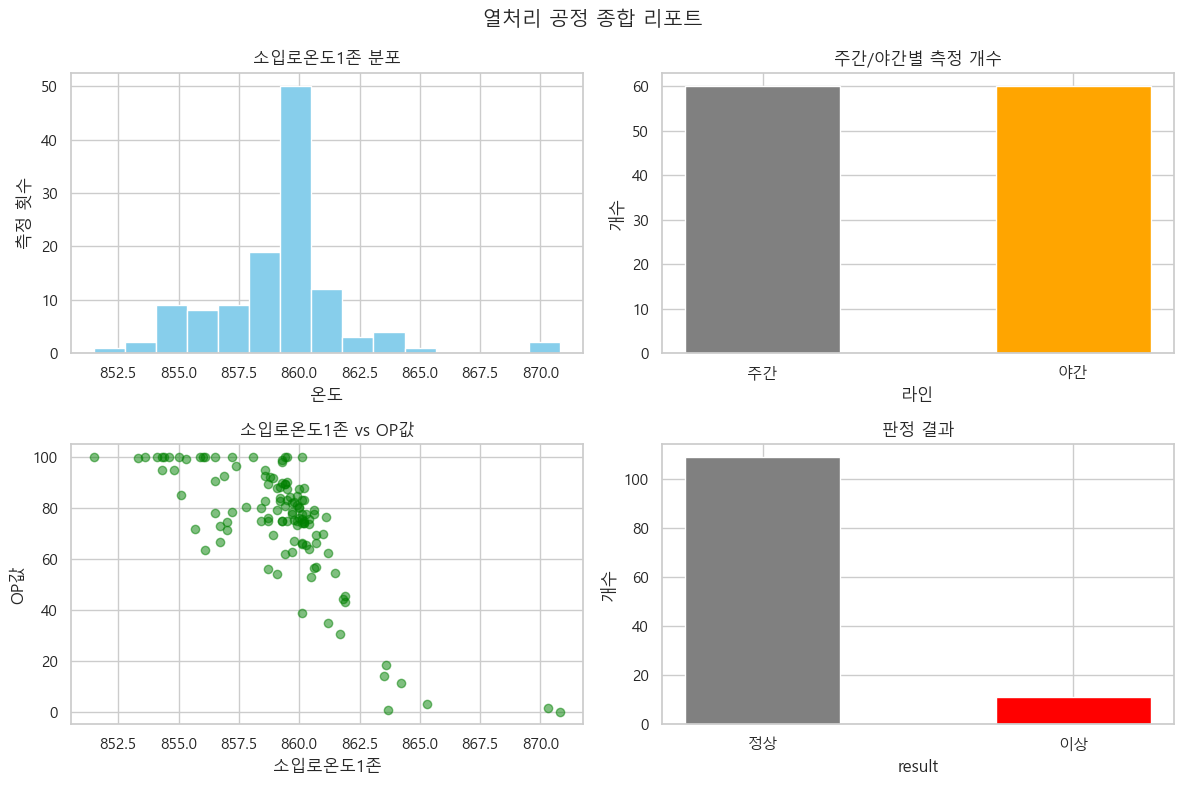

In [20]:
# 앞 실습에서 결측을 채운 df_7_fill을 그대로 사용
# figure를 먼저 만들고 suptitle로 전체 제목 달기
plt.figure(figsize=(12, 8))
plt.suptitle("열처리 공정 종합 리포트")

# subplot(2, 2, n) - 2행 2열 판의 n번 칸을 사용
plt.subplot(2, 2, 1)
plt.hist(df_7_fill["소입로온도1존"], bins=15, color="skyblue", edgecolor="white")
plt.title("소입로온도1존 분포")
plt.xlabel("온도")
plt.ylabel("측정 횟수")

plt.subplot(2, 2, 2)
counts_line = df_7_fill["라인"].value_counts()
plt.bar(counts_line.index, counts_line.values, color=["gray", "orange"], width=0.5)
plt.title("주간/야간별 측정 개수")
plt.xlabel("라인")
plt.ylabel("개수")

plt.subplot(2, 2, 3)
plt.scatter(df_7_fill["소입로온도1존"], df_7_fill["OP값"], alpha=0.5, color="green")
plt.title("소입로온도1존 vs OP값")
plt.xlabel("소입로온도1존")
plt.ylabel("OP값")

plt.subplot(2, 2, 4)
counts_result = df_7_fill["result"].value_counts()
plt.bar(counts_result.index, counts_result.values, color=["gray", "red"], width=0.5)
plt.title("판정 결과")
plt.xlabel("result")
plt.ylabel("개수")

plt.tight_layout()  # 칸 겹침 제거, 습관적으로 show 앞에 적용

# savefig로 이미지 저장
plt.savefig("17_02_실습8_종합리포트.png", dpi=150, bbox_inches="tight")
plt.show()